<a href="https://colab.research.google.com/github/carlos-osorio/monitor-portuario/blob/main/Monitor_puertos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests
import pandas as pd

print("requests:", requests.__version__)
print("pandas:", pd.__version__)

requests: 2.32.4
pandas: 2.2.2


In [3]:
# Dirección de la ventanilla (sin los parámetros)
url = "https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Ports_Data/FeatureServer/0/query"

# La "orden": la escribimos como diccionario para que sea legible,
# y requests se encarga de armarla y codificarla en la URL
params = {
    "where": "1=1",             # todas las filas...
    "outFields": "*",           # ...con todas las columnas...
    "resultRecordCount": 5,     # ...pero SOLO 5 registros de muestra
    "f": "json",                # formato de respuesta
}

respuesta = requests.get(url, params=params, timeout=60)
print("Código de estado:", respuesta.status_code)

datos = respuesta.json()          # convierte el texto JSON a diccionarios de Python
print("Llaves de la respuesta:", list(datos.keys()))

Código de estado: 200
Llaves de la respuesta: ['objectIdFieldName', 'uniqueIdField', 'globalIdFieldName', 'fields', 'exceededTransferLimit', 'features']


In [4]:
# ¿Qué columnas ofrece el dataset?
for campo in datos["fields"]:
    print(campo["name"], "→", campo["type"])

print("\n--- Un registro de ejemplo ---")
print(datos["features"][0]["attributes"])

date → esriFieldTypeDateOnly
year → esriFieldTypeInteger
month → esriFieldTypeInteger
day → esriFieldTypeInteger
portid → esriFieldTypeString
portname → esriFieldTypeString
country → esriFieldTypeString
ISO3 → esriFieldTypeString
portcalls_container → esriFieldTypeInteger
portcalls_dry_bulk → esriFieldTypeInteger
portcalls_general_cargo → esriFieldTypeInteger
portcalls_roro → esriFieldTypeInteger
portcalls_tanker → esriFieldTypeInteger
portcalls_cargo → esriFieldTypeInteger
portcalls → esriFieldTypeInteger
import_container → esriFieldTypeInteger
import_dry_bulk → esriFieldTypeInteger
import_general_cargo → esriFieldTypeInteger
import_roro → esriFieldTypeInteger
import_tanker → esriFieldTypeInteger
import_cargo → esriFieldTypeInteger
import → esriFieldTypeInteger
export_container → esriFieldTypeInteger
export_dry_bulk → esriFieldTypeInteger
export_general_cargo → esriFieldTypeInteger
export_roro → esriFieldTypeInteger
export_tanker → esriFieldTypeInteger
export_cargo → esriFieldTypeInte

In [5]:
params_puertos = {
    "where": "ISO3 = 'COL'",        # solo filas de Colombia (texto va entre comillas simples)
    "outFields": "portid,portname", # solo las dos columnas que nos interesan
    "returnDistinctValues": "true", # sin repetidos: cada puerto una sola vez
    "f": "json",
}

resp = requests.get(url, params=params_puertos, timeout=60)
print("Código de estado:", resp.status_code)

puertos = [f["attributes"] for f in resp.json()["features"]]
for p in puertos:
    print(p["portid"], "→", p["portname"])
print("\nTotal de puertos colombianos:", len(puertos))

Código de estado: 200
port120 → Barranquilla
port183 → Buenaventura
port218 → Cartagena
port266 → Covenas Offshore Term.
port1027 → Puerto Bolivar
port1054 → Puerto Nuevo
port1154 → Santa Marta
port2119 → Tumaco
port2278 → San Andres
port2407 → Turbo

Total de puertos colombianos: 10


In [6]:
params_conteo = {
    "where": "ISO3 = 'COL'",
    "returnCountOnly": "true",   # no me des datos, solo dime cuántas filas hay
    "f": "json",
}

resp = requests.get(url, params=params_conteo, timeout=60)
print("Filas totales de Colombia en la base:", resp.json()["count"])

Filas totales de Colombia en la base: 27340


In [7]:
# Diccionario con los 10 puertos que descubrimos
puertos_col = {
    "port120": "Barranquilla", "port183": "Buenaventura",
    "port218": "Cartagena", "port266": "Covenas",
    "port1027": "Puerto Bolivar", "port1054": "Puerto Nuevo",
    "port1154": "Santa Marta", "port2119": "Tumaco",
    "port2278": "San Andres", "port2407": "Turbo",
}

for pid, nombre in puertos_col.items():
    params = {
        "where": f"portid = '{pid}'",   # la f antes de la comilla inserta el valor de pid
        "returnCountOnly": "true",
        "f": "json",
    }
    resp = requests.get(url, params=params, timeout=60)
    print(nombre, "→", resp.json()["count"], "filas")

Barranquilla → 2734 filas
Buenaventura → 2734 filas
Cartagena → 2734 filas
Covenas → 2734 filas
Puerto Bolivar → 2734 filas
Puerto Nuevo → 2734 filas
Santa Marta → 2734 filas
Tumaco → 2734 filas
San Andres → 2734 filas
Turbo → 2734 filas


In [8]:
url_meta = url.rsplit("/query", 1)[0]   # quita el "/query" del final
resp = requests.get(url_meta, params={"f": "json"}, timeout=60)
meta = resp.json()
print("Máximo de registros por petición:", meta.get("maxRecordCount"))

Máximo de registros por petición: 1000


In [9]:
def descargar_puerto(pid):
    """Descarga TODAS las filas de un puerto, en tandas de 1000."""
    todas = []
    offset = 0
    while True:
        params = {
            "where": f"portid = '{pid}'",
            "outFields": "date,portname,portcalls,portcalls_container,import,export",
            "orderByFields": "date",        # ← crítico: orden estable entre tandas
            "resultOffset": offset,          # "empieza desde la fila N"
            "resultRecordCount": 1000,       # "dame 1000"
            "f": "json",
        }
        r = requests.get(url, params=params, timeout=60)
        r.raise_for_status()                 # si el estado no es 200, detente con error
        tanda = [f["attributes"] for f in r.json()["features"]]
        todas.extend(tanda)
        print(f"  offset {offset}: llegaron {len(tanda)} filas")
        if len(tanda) < 1000:                # tanda incompleta = era la última
            break
        offset += 1000
    return pd.DataFrame(todas)

bun = descargar_puerto("port183")
print("\nTotal descargado:", len(bun), "filas")
bun.head()

  offset 0: llegaron 1000 filas
  offset 1000: llegaron 1000 filas
  offset 2000: llegaron 734 filas

Total descargado: 2734 filas


,date,portname,portcalls,portcalls_container,import,export
0,2019-01-01,Buenaventura,0,0,0,0
1,2019-01-02,Buenaventura,0,0,0,0
2,2019-01-03,Buenaventura,0,0,0,0
3,2019-01-04,Buenaventura,0,0,0,0
4,2019-01-05,Buenaventura,0,0,0,0


In [10]:
bun["date"] = pd.to_datetime(bun["date"])
print("Rango de fechas:", bun["date"].min(), "→", bun["date"].max())
print("¿Fechas duplicadas?:", bun["date"].duplicated().sum())
print("¿Días calendario faltantes?:",
      len(pd.date_range(bun["date"].min(), bun["date"].max())) - len(bun))

Rango de fechas: 2019-01-01 00:00:00 → 2026-06-26 00:00:00
¿Fechas duplicadas?: 0
¿Días calendario faltantes?: 0


In [11]:
# Primer día con actividad real
primer_dia_activo = bun.loc[bun["portcalls"] > 0, "date"].min()
print("Primer día con portcalls > 0:", primer_dia_activo)

# ¿Cuántos días en cero hay por año? (si el problema es solo el arranque,
# 2019 tendrá muchos y los demás años pocos)
bun["anio"] = bun["date"].dt.year
print(bun[bun["portcalls"] == 0].groupby("anio").size())

Primer día con portcalls > 0: 2019-01-07 00:00:00
anio
2019    14
2020    19
2021    20
2022     6
2023     7
2024     5
2025     1
2026     2
dtype: int64


In [12]:
bun_sem = (
    bun.set_index("date")[["portcalls", "portcalls_container", "import", "export"]]
    .resample("W")     # agrupa por semanas calendario
    .sum()             # y suma cada semana
)
print(bun_sem.tail())  # las últimas semanas — ojo con la final, puede venir incompleta

            portcalls  portcalls_container  import  export
date                                                      
2026-05-31         23                   15  268847   67819
2026-06-07         24                   14  248633   71452
2026-06-14         18                   12  161101    7568
2026-06-21         29                   15  340062   32784
2026-06-28         17                    6  172732   18734


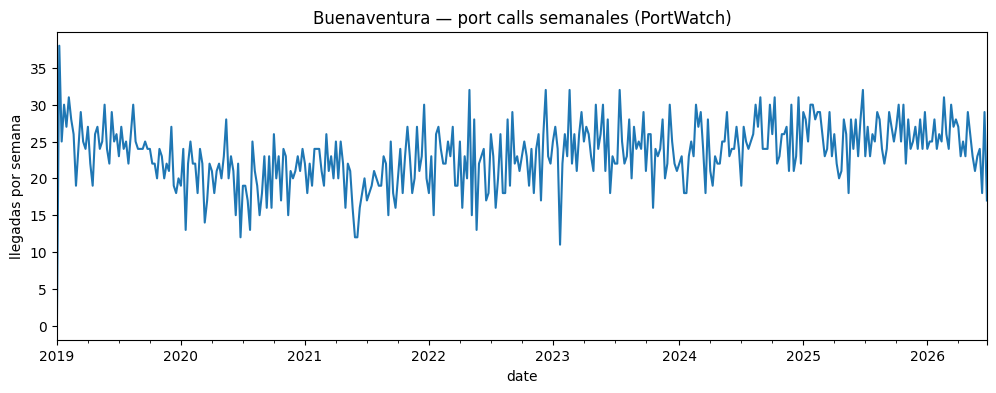

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
bun_sem["portcalls"].plot(ax=ax)
ax.set_title("Buenaventura — port calls semanales (PortWatch)")
ax.set_ylabel("llegadas por semana")
plt.show()

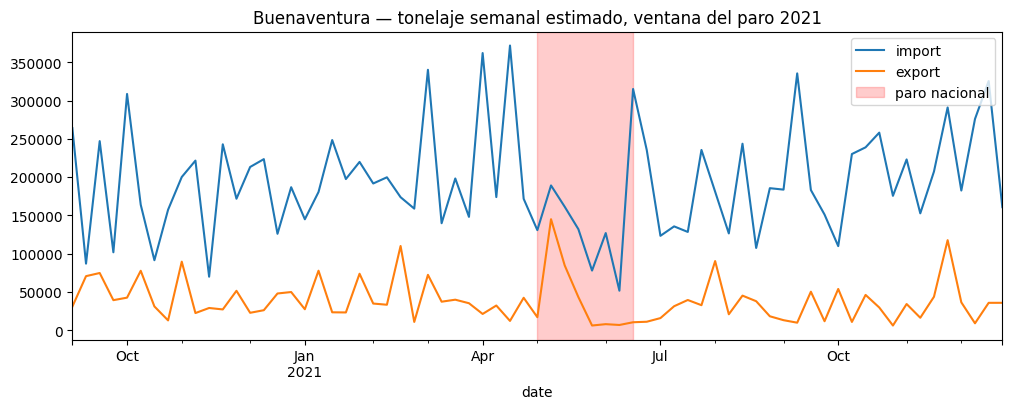

In [14]:
# (A) ¿El paro de 2021 sí se ve en el tonelaje?
fig, ax = plt.subplots(figsize=(12, 4))
bun_sem.loc["2020-09":"2021-12", ["import", "export"]].plot(ax=ax)
ax.axvspan(pd.Timestamp("2021-04-28"), pd.Timestamp("2021-06-15"),
           alpha=0.2, color="red", label="paro nacional")
ax.set_title("Buenaventura — tonelaje semanal estimado, ventana del paro 2021")
ax.legend()
plt.show()

In [15]:
# (B) Validación Poisson de los días-cero, año por año
import numpy as np

for anio, grupo in bun.groupby("anio"):
    lam = grupo["portcalls"].mean()                  # llegadas promedio/día
    esperados = len(grupo) * np.exp(-lam)            # días-cero esperados
    observados = (grupo["portcalls"] == 0).sum()
    print(f"{anio}: λ={lam:.2f} → ceros esperados ≈ {esperados:.0f}, observados = {observados}")

2019: λ=3.46 → ceros esperados ≈ 11, observados = 14
2020: λ=2.89 → ceros esperados ≈ 20, observados = 19
2021: λ=2.95 → ceros esperados ≈ 19, observados = 20
2022: λ=3.19 → ceros esperados ≈ 15, observados = 6
2023: λ=3.47 → ceros esperados ≈ 11, observados = 7
2024: λ=3.52 → ceros esperados ≈ 11, observados = 5
2025: λ=3.72 → ceros esperados ≈ 9, observados = 1
2026: λ=3.61 → ceros esperados ≈ 5, observados = 2


Descargando Buenaventura...
  offset 0: llegaron 1000 filas
  offset 1000: llegaron 1000 filas
  offset 2000: llegaron 734 filas
Descargando Cartagena...
  offset 0: llegaron 1000 filas
  offset 1000: llegaron 1000 filas
  offset 2000: llegaron 734 filas
Descargando Barranquilla...
  offset 0: llegaron 1000 filas
  offset 1000: llegaron 1000 filas
  offset 2000: llegaron 734 filas
Descargando Santa Marta...
  offset 0: llegaron 1000 filas
  offset 1000: llegaron 1000 filas
  offset 2000: llegaron 734 filas


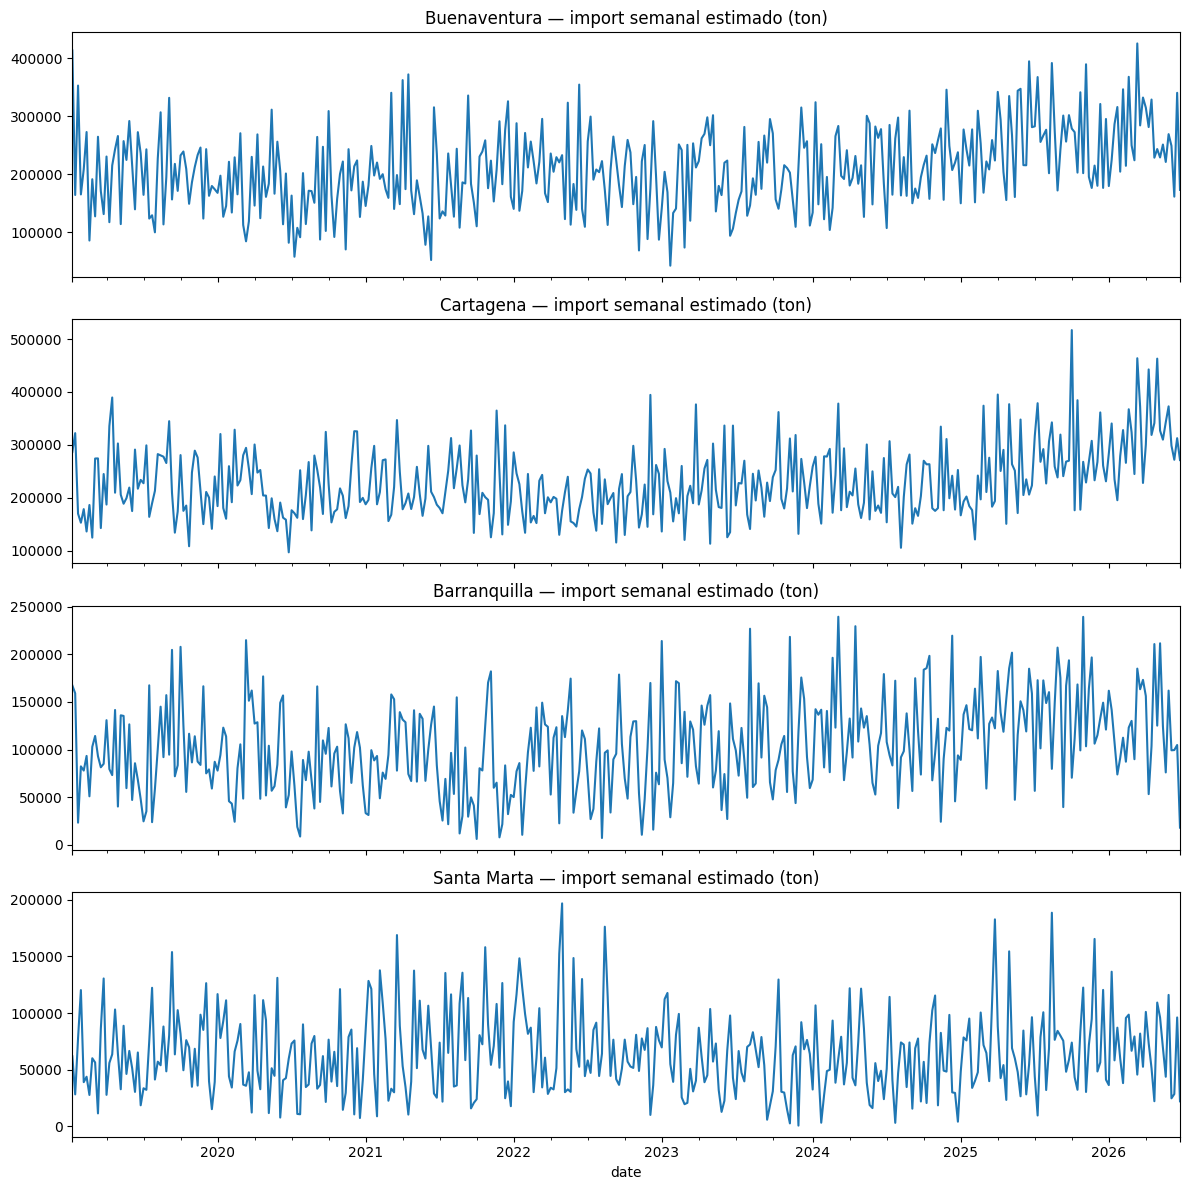

In [16]:
puertos_v1 = {
    "port183": "Buenaventura",
    "port218": "Cartagena",
    "port120": "Barranquilla",
    "port1154": "Santa Marta",
}

series = {}
for pid, nombre in puertos_v1.items():
    print(f"Descargando {nombre}...")
    df = descargar_puerto(pid)
    df["date"] = pd.to_datetime(df["date"])
    df = df[df["date"] >= "2019-01-07"]          # recorte de la semana muerta
    series[nombre] = (
        df.set_index("date")[["portcalls", "import", "export"]].resample("W").sum()
    )

# Panel 4x1 para comparar de un vistazo
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
for ax, (nombre, s) in zip(axes, series.items()):
    s["import"].plot(ax=ax)
    ax.set_title(f"{nombre} — import semanal estimado (ton)")
plt.tight_layout()
plt.show()

monitorea Buenaventura, Cartagena, Barranquilla y Santa Marta con datos semanales de PortWatch (serie desde 2019-01-07); indicador principal el tonelaje estimado import/export (único que alerta), port calls como contexto diagnóstico; corre miércoles por GitHub Actions; excluye siempre la última semana parcial; guarda snapshot fechado en cada corrida y mide revisiones retroactivas; salida en español: reporte semanal en GitHub Pages y dashboard en Streamlit; límite declarado: detección con 10-14 días de rezago, no herramienta operativa; éxito: 4 corridas consecutivas sin intervención manual y una alerta verificada contra la realidad.